In [5]:
#load IMDB dataset
from datasets import load_dataset

dataset = load_dataset("imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [6]:
#take a smaller subset
train_data = dataset["train"].shuffle(seed=42).select(range(5000))
test_data = dataset["test"].shuffle(seed=42).select(range(2000))

In [8]:
#preprocessing
def preprocess(example):
    example["text"] = example["text"].lower()
    return example

train_data = train_data.map(preprocess)
test_data = test_data.map(preprocess)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 22590.34 examples/s]


In [9]:
#data check
print(train_data[0])

{'text': 'there is no relation at all between fortier and profiler but the fact that both are police series about violent crimes. profiler looks crispy, fortier looks classic. profiler plots are quite simple. fortier\'s plot are far more complicated... fortier looks more like prime suspect, if we have to spot similarities... the main character is weak and weirdo, but have "clairvoyance". people like to compare, to judge, to evaluate. how about just enjoying? funny thing too, people writing fortier looks american but, on the other hand, arguing they prefer american series (!!!). maybe it\'s the language, or the spirit, but i think this series is more english than american. by the way, the actors are really good and funny. the acting is not superficial at all...', 'label': 1}


In [10]:
#convert to pandas
import pandas as pd

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

train_df.head()

,text,label
0,there is no relation at all between fortier an...,1
1,this movie is a great. the plot is very true t...,1
2,"george p. cosmatos' ""rambo: first blood part i...",0
3,in the process of trying to establish the audi...,1
4,"yeh, i know -- you're quivering with excitemen...",0


In [11]:
train_df = train_df.rename(columns={"label": "target"})
test_df = test_df.rename(columns={"label": "target"})

In [12]:
#baseline model, convert text to numbers (TF-IDF)
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train = vectorizer.fit_transform(train_df["text"])
X_test = vectorizer.transform(test_df["text"])

y_train = train_df["target"]
y_test = test_df["target"]

In [13]:
#train logistic regression
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
#evaluate
from sklearn.metrics import accuracy_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.856
F1 Score: 0.8588235294117647


In [15]:
#load tokenizer
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [16]:
#tokenize dataset
def tokenize(example):
    return tokenizer(example["text"], truncation=True, padding="max_length")

train_data = train_data.map(tokenize, batched=True)
test_data = test_data.map(tokenize, batched=True)

Map: 100%|██████████| 2000/2000 [00:00<00:00, 3115.51 examples/s]


In [17]:
#format
train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

In [18]:
#model
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4509.88it/s]
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider tr

In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,  # keep it small
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    logging_dir="./logs",
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [24]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=test_data,
)

In [22]:
#train
trainer.train()

c:\Users\reems\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
500,0.376397


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.18it/s]


TrainOutput(global_step=625, training_loss=0.36084762573242185, metrics={'train_runtime': 11758.7752, 'train_samples_per_second': 0.425, 'train_steps_per_second': 0.053, 'total_flos': 1315555276800000.0, 'train_loss': 0.36084762573242185, 'epoch': 1.0})

In [26]:
#eval
import torch
from sklearn.metrics import accuracy_score, f1_score

model.eval()

predictions = []
labels = []

for example in test_data:
    inputs = {
        "input_ids": example["input_ids"].unsqueeze(0),
        "attention_mask": example["attention_mask"].unsqueeze(0)
    }

    with torch.no_grad():
        outputs = model(**inputs)

    pred = torch.argmax(outputs.logits, dim=1).item()

    predictions.append(pred)
    labels.append(example["label"])

print("Accuracy:", accuracy_score(labels, predictions))
print("F1 Score:", f1_score(labels, predictions))

Accuracy: 0.9155
F1 Score: 0.9162121963311849


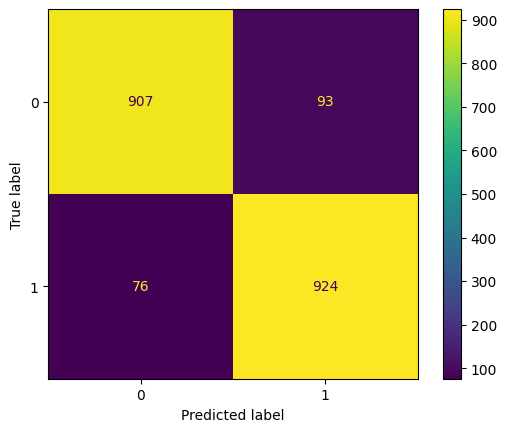

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(labels, predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [28]:
from sklearn.metrics import precision_score, recall_score

print("Precision:", precision_score(labels, predictions))
print("Recall:", recall_score(labels, predictions))

Precision: 0.9085545722713865
Recall: 0.924


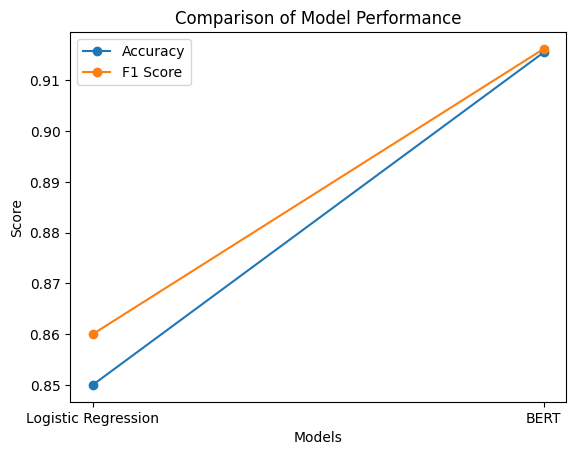

In [3]:
import matplotlib.pyplot as plt

models = ["Logistic Regression", "BERT"]
accuracy = [0.85, 0.9155]
f1_scores = [0.86, 0.9162]

x = range(len(models))

plt.figure()

plt.plot(models, accuracy, marker='o', label="Accuracy")
plt.plot(models, f1_scores, marker='o', label="F1 Score")

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Comparison of Model Performance")
plt.legend()

plt.show()